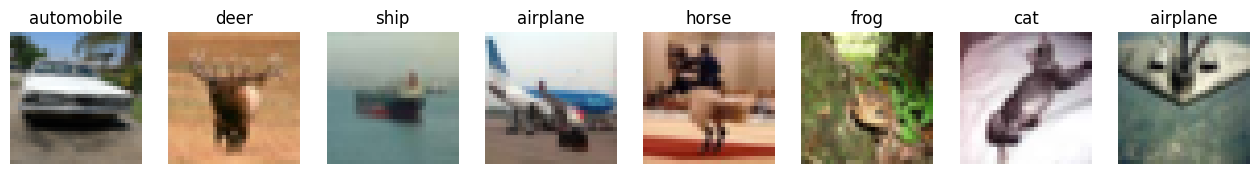

In [34]:
images, labels = next(iter(dataloader))
classes = dataset.classes

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0)
    img = (img + 1) / 2
    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()


In [35]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

print(alphas_cumprod[0])
print(alphas_cumprod[-1])


device: mps
tensor(0.9999, device='mps:0')
tensor(4.0358e-05, device='mps:0')


In [36]:
def add_noise(x_0, t):
    noise = torch.randn_like(x_0)
    sqrt_alpha_bar = torch.sqrt(alphas_cumprod[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar = torch.sqrt(1 - alphas_cumprod[t]).view(-1, 1, 1, 1)
    x_t = sqrt_alpha_bar * x_0 + sqrt_one_minus_alpha_bar * noise
    return x_t, noise


In [37]:
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=('DownBlock2D', 'DownBlock2D', 'AttnDownBlock2D'),
    up_block_types=('AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D'),
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net params: {n_params / 1e6:.1f}M')


U-Net params: 15.7M


In [38]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
epochs = 5

model.train()
for epoch in range(epochs):
    for images, _ in dataloader:
        images = images.to(device)
        t = torch.randint(0, T, (images.shape[0],), device=device)
        x_t, noise = add_noise(images, t)
        predicted_noise = model(x_t, t).sample
        loss = F.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch} | Loss: {loss.item():.4f}')


Epoch 0 | Loss: 0.0449
Epoch 1 | Loss: 0.0485
Epoch 2 | Loss: 0.0372
Epoch 3 | Loss: 0.0448
Epoch 4 | Loss: 0.0299


In [39]:
@torch.no_grad()
def sample(model, n_images=8):
    model.eval()
    x = torch.randn(n_images, 3, 32, 32, device=device)

    for t in reversed(range(T)):
        t_batch = torch.full((n_images,), t, device=device, dtype=torch.long)
        predicted_noise = model(x, t_batch).sample

        alpha_t = alphas[t]
        alpha_bar_t = alphas_cumprod[t]
        beta_t = betas[t]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        mean = (1 / torch.sqrt(alpha_t)) * (x - coef * predicted_noise)

        if t > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = mean + torch.sqrt(beta_t) * z

    return x


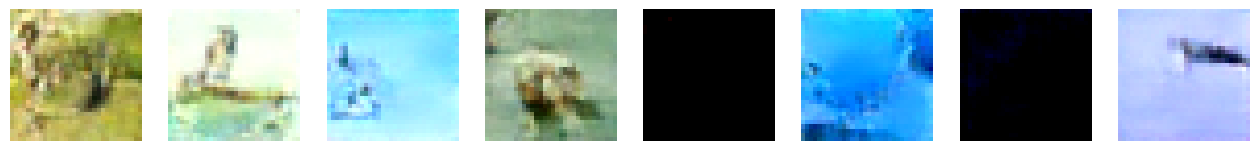

In [40]:
generated = sample(model, n_images=8)
generated = (generated.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = generated[i].permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.axis('off')
plt.show()


In [41]:
dataloader_fast = torch.utils.data.DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
)

model_fast = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 256),
    down_block_types=('DownBlock2D', 'DownBlock2D', 'DownBlock2D'),
    up_block_types=('UpBlock2D', 'UpBlock2D', 'UpBlock2D'),
).to(device)
